## 1) Preparação do ambiente e caminhos
Obs.: o `load_config()` do webapp lê `static/config/config.json` via caminho relativo; por isso ajustamos o diretório de trabalho para o diretório do webapp.

In [5]:
from pathlib import Path
import os
import sys
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt

ZONAS_DIR = Path.cwd().resolve()
WEBAPP_DIR = (ZONAS_DIR.parent / 'webapp-risco-inundacao').resolve()

if not WEBAPP_DIR.exists():
    raise FileNotFoundError(f'WEBAPP_DIR não encontrado: {WEBAPP_DIR}')

HECRAS_RASTER = (ZONAS_DIR / 'dados' / 'raster-mancha-inundacao-recife.tif').resolve()
if not HECRAS_RASTER.exists():
    raise FileNotFoundError(f'Raster do HEC-RAS não encontrado: {HECRAS_RASTER}')

sys.path.insert(0, str(WEBAPP_DIR))
os.chdir(WEBAPP_DIR)

from services.analise_service import AnaliseService
from services.municipio_service import MunicipioService
from utils.utils import load_config

print('CWD:', Path.cwd())
print('HECRAS_RASTER:', HECRAS_RASTER)

CWD: /Users/fabio/Library/CloudStorage/GoogleDrive-fabio.novaes@ufrpe.br/Meu Drive/Pesquisa UABJ/MC-UFRPE/inundações-ezequiel/artigo-pso-multicritério/ahp_fabio/webapp-risco-inundacao
HECRAS_RASTER: /Users/fabio/Library/CloudStorage/GoogleDrive-fabio.novaes@ufrpe.br/Meu Drive/Pesquisa UABJ/MC-UFRPE/inundações-ezequiel/artigo-pso-multicritério/ahp_fabio/zonas-de-risco-inundacao/dados/raster-mancha-inundacao-recife.tif


## 2) Rodar o pipeline do webapp (gerar rasters reclassificados)
Isso cria/atualiza os rasters em `outputs/` do webapp, incluindo os `*_reclass.tif`.

In [6]:
NOME_CIDADE = 'Recife'
SLUG = NOME_CIDADE.strip().lower().replace(' ', '-')

cfg = load_config() or {}
print('Cidades suportadas:', cfg.get('cidades_suportadas'))

municipios = MunicipioService('dados/PE_Municipios_2023/PE_Municipios_2023.shp')
gdf = municipios.get_gdf_municipio(NOME_CIDADE)

analise = AnaliseService()
risco_recortado_path = analise.executar(NOME_CIDADE, gdf)
print('Risco (recortado) gerado pelo webapp:', risco_recortado_path)

# Salvar uma cópia do AHP inicial (antes da calibração sobrescrever o TIFF padrão)
from shutil import copyfile

risco_inicial_path = Path(f'outputs/mapas_de_risco/risco_alagamento_{SLUG}.tif')
risco_inicial_recortado_path = Path(f'outputs/mapas_de_risco/risco_alagamento_{SLUG}_recortado_inicial.tif')

if Path(risco_recortado_path).exists():
    copyfile(risco_recortado_path, risco_inicial_recortado_path)
    print('Cópia (inicial) salva em:', risco_inicial_recortado_path)
else:
    raise FileNotFoundError(f'Risco recortado não encontrado: {risco_recortado_path}')

if risco_inicial_path.exists():
    copyfile(risco_inicial_path, Path(f'outputs/mapas_de_risco/risco_alagamento_{SLUG}_inicial.tif'))

Cidades suportadas: ['Recife', 'Belo Jardim']


/Users/fabio/Library/CloudStorage/GoogleDrive-fabio.novaes@ufrpe.br/Meu Drive/Pesquisa UABJ/MC-UFRPE/inundações-ezequiel/artigo-pso-multicritério/ahp_fabio/webapp-risco-inundacao/services/analise_service.py:89: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf.geometry.centroid.iloc[0]


Risco (recortado) gerado pelo webapp: outputs/mapas_de_risco/risco_alagamento_recife_recortado.tif
Cópia (inicial) salva em: outputs/mapas_de_risco/risco_alagamento_recife_recortado_inicial.tif


## 3) Alinhar o raster do HEC-RAS ao grid do webapp
Reprojetamos para a moldura e recortamos ao limite do município para permitir comparação pixel-a-pixel.

In [7]:
def align_raster_to_reference(input_path: Path, reference_path: Path, output_path: Path, resampling=Resampling.bilinear):
    input_path = Path(input_path)
    reference_path = Path(reference_path)
    output_path = Path(output_path)

    with rasterio.open(reference_path) as ref:
        ref_crs = ref.crs
        ref_transform = ref.transform
        ref_w = ref.width
        ref_h = ref.height

    with rasterio.open(input_path) as src:
        src_data = src.read(1)
        src_nodata = src.nodata
        src_profile = src.profile.copy()

        dst = np.full((ref_h, ref_w), np.nan, dtype=np.float32)
        reproject(
            source=src_data.astype(np.float32, copy=False),
            destination=dst,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=resampling,
            src_nodata=src_nodata,
            dst_nodata=np.nan,
        )

    profile = src_profile
    profile.update({
        'crs': ref_crs,
        'transform': ref_transform,
        'width': ref_w,
        'height': ref_h,
        'dtype': rasterio.float32,
        'count': 1,
        'nodata': np.nan,
    })

    output_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(output_path, 'w', **profile) as dstf:
        dstf.write(dst.astype(np.float32, copy=False), 1)

    return output_path

def recortar_por_municipio(raster_path: Path, limite_shp: Path, output_path: Path, nodata=np.nan):
    gdf_lim = gpd.read_file(limite_shp)
    geoms = gdf_lim.geometry.values
    with rasterio.open(raster_path) as src:
        out_image, out_transform = mask(src, geoms, crop=True, filled=True, nodata=nodata)
        out_meta = src.meta.copy()
        out_meta.update({
            'height': out_image.shape[1],
            'width': out_image.shape[2],
            'transform': out_transform,
            'dtype': out_image.dtype,
            'nodata': nodata,
        })
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(output_path, 'w', **out_meta) as dst:
        dst.write(out_image)
    return output_path

In [8]:
moldura = Path(f'outputs/molduras_municipios/moldura-{SLUG}.tif')
limite_shp = Path(f'outputs/limites_municipios/limite_{SLUG}_reprojetado.shp')

if not moldura.exists():
    raise FileNotFoundError(f'Moldura não encontrada: {moldura}')
if not limite_shp.exists():
    raise FileNotFoundError(f'Limite reprojetado não encontrado: {limite_shp}')

hecras_alinhado = Path(f'outputs/hecras/hecras_{SLUG}_alinhado_moldura.tif')
hecras_recortado = Path(f'outputs/hecras/hecras_{SLUG}_recortado.tif')

align_raster_to_reference(HECRAS_RASTER, moldura, hecras_alinhado, resampling=Resampling.bilinear)
recortar_por_municipio(hecras_alinhado, limite_shp, hecras_recortado, nodata=np.nan)

print('HEC-RAS alinhado:', hecras_alinhado)
print('HEC-RAS recortado:', hecras_recortado)

HEC-RAS alinhado: outputs/hecras/hecras_recife_alinhado_moldura.tif
HEC-RAS recortado: outputs/hecras/hecras_recife_recortado.tif


## 4) Preparar alvo (mancha) e carregar critérios reclassificados
O alvo é construído a partir do raster do HEC-RAS recortado. Se ele parecer binário (poucos valores únicos), convertemos para 1 (não inundado) e 4 (inundado). Caso contrário, normalizamos para 1..4.

In [9]:
def read_as_float(path: Path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32, copy=False)
        nodata = src.nodata
    if nodata is not None and np.isfinite(nodata):
        arr = np.where(arr == nodata, np.nan, arr)
    return arr

def prepare_hecras_target(arr: np.ndarray):
    valid = np.isfinite(arr)
    if not valid.any():
        raise ValueError('HEC-RAS sem pixels válidos após alinhamento/recorte')
    vals = arr[valid]
    uniq = np.unique(vals)

    # Heurística de máscara/binário
    if uniq.size <= 5:
        vmin, vmax = float(np.min(vals)), float(np.max(vals))
        flooded = arr > (vmin + (vmax - vmin) * 0.5) if vmax > vmin else (arr > vmin)
        target = np.full(arr.shape, np.nan, dtype=np.float32)
        target[valid & (~flooded)] = 1.0
        target[valid & flooded] = 4.0
        return target

    # Caso contínuo
    dmin, dmax = float(np.min(vals)), float(np.max(vals))
    if dmax == dmin:
        target = np.full(arr.shape, np.nan, dtype=np.float32)
        target[valid] = 2.5
        return target
    norm = (arr - dmin) / (dmax - dmin)
    target = 1.0 + norm * 3.0
    target[~valid] = np.nan
    return target.astype(np.float32, copy=False)

uso_reclass = Path(f'outputs/uso_do_solo/uso_do_solo_{SLUG}_reclass.tif')
decl_reclass = Path(f'outputs/declividade/declividade_{SLUG}_reclass.tif')
fluxo_reclass = Path(f'outputs/fluxo_acumulado/fluxo_acumulado_{SLUG}_reclass.tif')
hipso_reclass = Path(f'outputs/hipsometria/hipsometria_{SLUG}_reclass.tif')

for p in [uso_reclass, decl_reclass, fluxo_reclass, hipso_reclass]:
    if not p.exists():
        raise FileNotFoundError(f'Raster reclassificado ausente: {p}')

uso = read_as_float(uso_reclass)
decl = read_as_float(decl_reclass)
fluxo = read_as_float(fluxo_reclass)
hipso = read_as_float(hipso_reclass)

from rasterio.features import rasterize

# IMPORTANTE: os critérios reclassificados estão no grid da moldura (não recortados).
# Para evitar mismatch de shape, usamos o HEC-RAS alinhado à moldura (sem recorte) e
# aplicamos uma máscara rasterizada do município.
with rasterio.open(moldura) as ref:
    ref_transform = ref.transform
    ref_crs = ref.crs
    out_shape = (ref.height, ref.width)

gdf_lim = gpd.read_file(limite_shp)
if gdf_lim.crs != ref_crs:
    gdf_lim = gdf_lim.to_crs(ref_crs)

municipio_mask = rasterize(
    [(geom, 1) for geom in gdf_lim.geometry],
    out_shape=out_shape,
    transform=ref_transform,
    fill=0,
    dtype=np.uint8,
).astype(bool)

hecras = read_as_float(hecras_alinhado)
target = prepare_hecras_target(hecras)
target[~municipio_mask] = np.nan

mask_valid = municipio_mask & (uso > 0) & (decl > 0) & (fluxo > 0) & (hipso > 0) & np.isfinite(target)
print('Pixels válidos para calibração:', int(mask_valid.sum()))

Pixels válidos para calibração: 3381


## 5) AHP (mesmo cálculo do webapp) + objetivo
Otimizamos as 6 comparações pareadas e penalizamos CR acima de 0,10.

In [10]:
def ahp_weights_and_cr(pairwise_6):
    (u_d, u_f, u_h, d_f, d_h, f_h) = [float(x) for x in pairwise_6]
    if any((not np.isfinite(x) or x <= 0) for x in [u_d, u_f, u_h, d_f, d_h, f_h]):
        return None, None

    A = np.array([
        [1,        u_d,      u_f,      u_h],
        [1/u_d,    1,        d_f,      d_h],
        [1/u_f,    1/d_f,    1,        f_h],
        [1/u_h,    1/d_h,    1/f_h,    1],
    ], dtype=float)

    vals, vecs = np.linalg.eig(A)
    idx = int(np.argmax(vals.real))
    w = vecs[:, idx].real
    w = w / w.sum()

    n = A.shape[0]
    lambda_max = float(vals[idx].real)
    CI = (lambda_max - n) / (n - 1)
    RI_table = {1:0.00, 2:0.00, 3:0.58, 4:0.90, 5:1.12, 6:1.24, 7:1.32, 8:1.41, 9:1.45, 10:1.49}
    RI = RI_table.get(n, 0.90)
    CR = float(CI / RI) if RI > 0 else 0.0

    return w.astype(float, copy=False), CR

def objective(pairwise_6, cr_threshold=0.10, cr_penalty=5.0):
    w, cr = ahp_weights_and_cr(pairwise_6)
    if w is None:
        return float('inf')
    risk = (w[0] * uso) + (w[1] * decl) + (w[2] * fluxo) + (w[3] * hipso)
    diff = risk[mask_valid] - target[mask_valid]
    mse = float(np.mean(diff * diff))
    pen = 0.0 if cr <= cr_threshold else cr_penalty * float((cr - cr_threshold) ** 2)
    return mse + pen

## 6) PSO para otimizar as 6 comparações pareadas
Busca em [1/9, 9] para cada comparação.

In [11]:
class Particle:
    def __init__(self, x0, bounds):
        self.position = np.array(x0, dtype=float)
        self.velocity = np.random.uniform(-0.5, 0.5, len(x0))
        self.pos_best = np.copy(self.position)
        self.err_best = float('inf')
        self.err = float('inf')
        self.bounds = bounds

    def evaluate(self, func):
        self.err = func(self.position)
        if self.err < self.err_best:
            self.err_best = self.err
            self.pos_best = np.copy(self.position)

    def update_velocity(self, global_best, w=0.6, c1=1.2, c2=1.6):
        r1 = np.random.random(len(self.position))
        r2 = np.random.random(len(self.position))
        cognitive = c1 * r1 * (self.pos_best - self.position)
        social = c2 * r2 * (global_best - self.position)
        self.velocity = w * self.velocity + cognitive + social

    def update_position(self):
        self.position = self.position + self.velocity
        for i in range(len(self.position)):
            lo, hi = self.bounds[i]
            self.position[i] = np.clip(self.position[i], lo, hi)

class PSO:
    def __init__(self, cost_function, initial, bounds, n_particles=30, max_iter=40, seed=42):
        np.random.seed(seed)
        swarm = [Particle(initial, bounds) for _ in range(n_particles)]

        global_best_pos = np.array(initial, dtype=float)
        global_best_err = float('inf')
        history = []

        for it in range(max_iter):
            for particle in swarm:
                particle.evaluate(cost_function)
                if particle.err < global_best_err:
                    global_best_err = particle.err
                    global_best_pos = np.copy(particle.position)

            for particle in swarm:
                particle.update_velocity(global_best_pos)
                particle.update_position()

            history.append(global_best_err)
            print(f'Iteração {it+1}/{max_iter} | Melhor custo = {global_best_err:.6f}')

        self.best_pos = global_best_pos
        self.best_err = global_best_err
        self.history = history

Iteração 1/40 | Melhor custo = 2.285932
Iteração 2/40 | Melhor custo = 2.059570
Iteração 3/40 | Melhor custo = 1.991295
Iteração 4/40 | Melhor custo = 1.817807
Iteração 5/40 | Melhor custo = 1.787363
Iteração 6/40 | Melhor custo = 1.737895
Iteração 7/40 | Melhor custo = 1.715432
Iteração 8/40 | Melhor custo = 1.697151
Iteração 9/40 | Melhor custo = 1.669564
Iteração 10/40 | Melhor custo = 1.625732
Iteração 11/40 | Melhor custo = 1.546023
Iteração 12/40 | Melhor custo = 1.538046
Iteração 13/40 | Melhor custo = 1.517035
Iteração 14/40 | Melhor custo = 1.486617
Iteração 15/40 | Melhor custo = 1.486617
Iteração 16/40 | Melhor custo = 1.463403
Iteração 17/40 | Melhor custo = 1.445954
Iteração 18/40 | Melhor custo = 1.418736
Iteração 19/40 | Melhor custo = 1.354336
Iteração 20/40 | Melhor custo = 1.306559
Iteração 21/40 | Melhor custo = 1.207977
Iteração 22/40 | Melhor custo = 1.066674
Iteração 23/40 | Melhor custo = 0.940622
Iteração 24/40 | Melhor custo = 0.748460
Iteração 25/40 | Melhor c

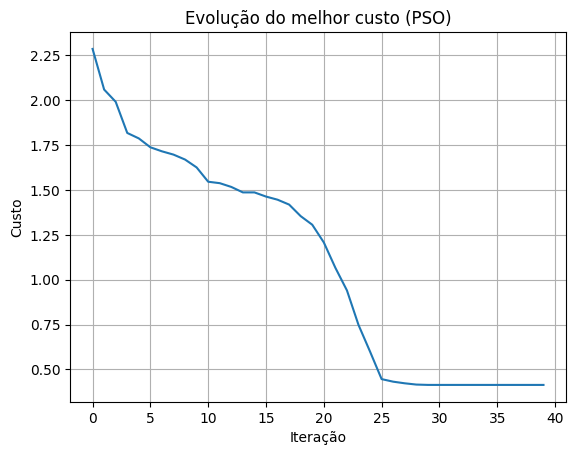

In [12]:
pesos_cfg = (cfg.get('pesos') or {})
initial = [
    float(pesos_cfg.get('uso_vs_declividade', 1/5)),
    float(pesos_cfg.get('uso_vs_fluxo', 3)),
    float(pesos_cfg.get('uso_vs_hipsometria', 1/5)),
    float(pesos_cfg.get('declividade_vs_fluxo', 3)),
    float(pesos_cfg.get('declividade_vs_hipsometria', 1)),
    float(pesos_cfg.get('fluxo_vs_hipsometria', 1/5)),
]

bounds = [(1/9, 9)] * 6
pso = PSO(objective, initial, bounds, n_particles=30, max_iter=40, seed=42)
best_pairwise = pso.best_pos
best_w, best_cr = ahp_weights_and_cr(best_pairwise)

print('\n=== RESULTADO FINAL ===')
print('Melhor custo:', pso.best_err)
print('Pairwise (6):', best_pairwise)
print('Pesos (uso, decl, fluxo, hipso):', best_w)
print('CR:', best_cr)

plt.plot(pso.history)
plt.title('Evolução do melhor custo (PSO)')
plt.xlabel('Iteração')
plt.ylabel('Custo')
plt.grid(True)
plt.show()

## 7) Gerar mapa de risco com os pesos calibrados
Usa a mesma função interna do webapp para gerar o TIFF e o recorte.

In [13]:
analise._gerar_mapa_risco(best_w)

risco_path = Path(f'outputs/mapas_de_risco/risco_alagamento_{SLUG}.tif')
risco_recortado_path = Path(f'outputs/mapas_de_risco/risco_alagamento_{SLUG}_recortado.tif')
analise._recortar_mapa(str(risco_path), str(risco_recortado_path))

# Salvar uma cópia do AHP calibrado
from shutil import copyfile
risco_calibrado_path = Path(f'outputs/mapas_de_risco/risco_alagamento_{SLUG}_calibrado.tif')
risco_calibrado_recortado_path = Path(f'outputs/mapas_de_risco/risco_alagamento_{SLUG}_recortado_calibrado.tif')
copyfile(risco_path, risco_calibrado_path)
copyfile(risco_recortado_path, risco_calibrado_recortado_path)

print('Risco (TIFF):', risco_path)
print('Risco (recortado):', risco_recortado_path)
print('Cópia (calibrado):', risco_calibrado_recortado_path)

Risco (TIFF): outputs/mapas_de_risco/risco_alagamento_recife.tif
Risco (recortado): outputs/mapas_de_risco/risco_alagamento_recife_recortado.tif
Cópia (calibrado): outputs/mapas_de_risco/risco_alagamento_recife_recortado_calibrado.tif


## 8) Visualização rápida (alvo vs risco)

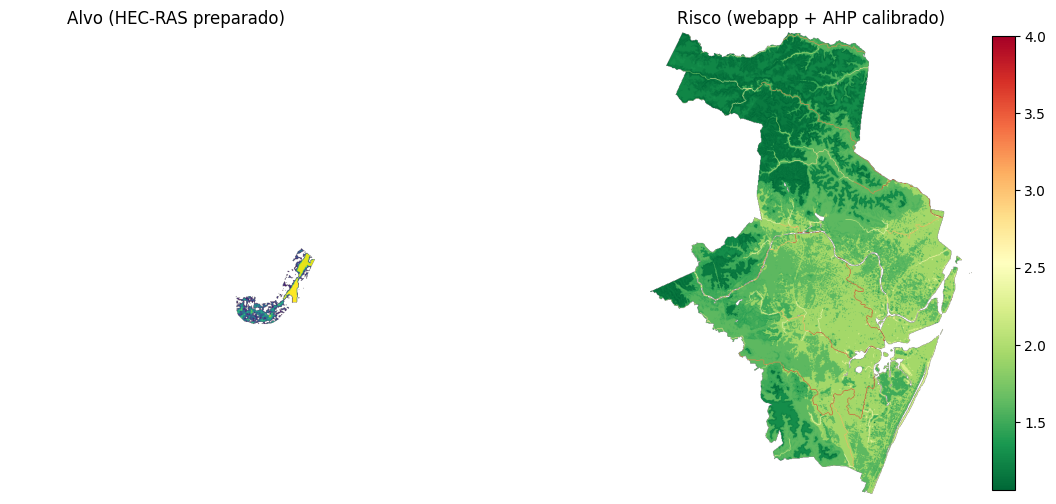

In [14]:
with rasterio.open(risco_recortado_path) as src:
    risco_rec = src.read(1).astype(np.float32, copy=False)
    nodata = src.nodata
    if nodata is not None and np.isfinite(nodata):
        risco_rec = np.where(risco_rec == nodata, np.nan, risco_rec)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(target, cmap='viridis')
axes[0].set_title('Alvo (HEC-RAS preparado)')
axes[0].axis('off')

im = axes[1].imshow(risco_rec, cmap='RdYlGn_r')
axes[1].set_title('Risco (webapp + AHP calibrado)')
axes[1].axis('off')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.show()

## 9) Mapa interativo (Folium): HEC-RAS vs AHP inicial vs AHP calibrado
Este mapa cria **3 camadas** no Folium:
- **HEC-RAS** (raster recortado)
- **AHP inicial** (raster recortado salvo antes do PSO)
- **AHP calibrado** (raster recortado após o PSO)

/var/folders/cw/3qg16z450yvf__sw0f3gp2hw0000gn/T/ipykernel_46833/2990950346.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centro = gdf4326.geometry.centroid.iloc[0]
/var/folders/cw/3qg16z450yvf__sw0f3gp2hw0000gn/T/ipykernel_46833/2990950346.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  img_hec, bounds_hec, op_hec = raster_to_overlay_rgba(hecras_layer_path, cmap=cm.get_cmap('viridis'), opacity=0.6)
/var/folders/cw/3qg16z450yvf__sw0f3gp2hw0000gn/T/ipykernel_46833/2990950346.py:108: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cma


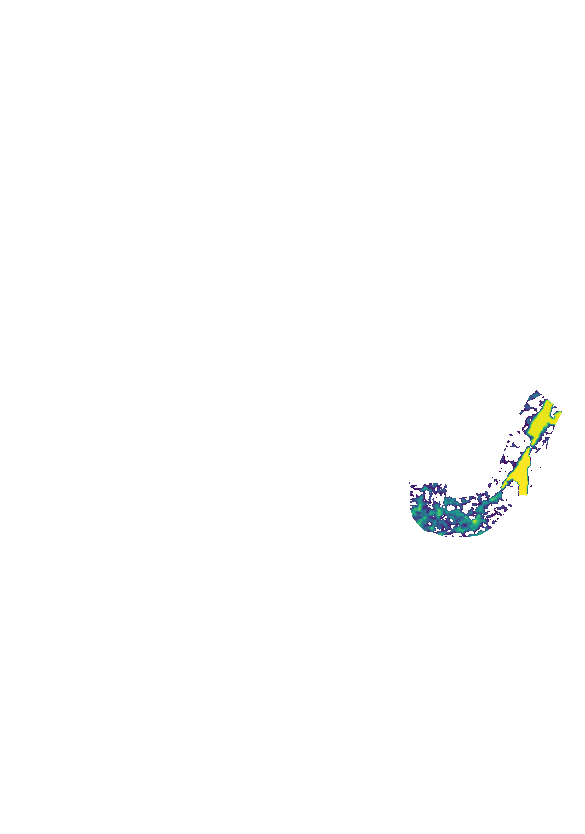
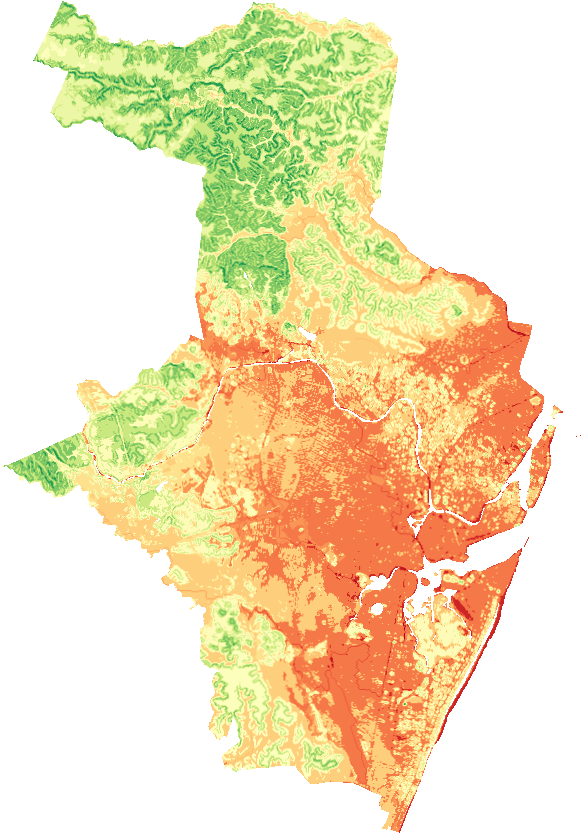
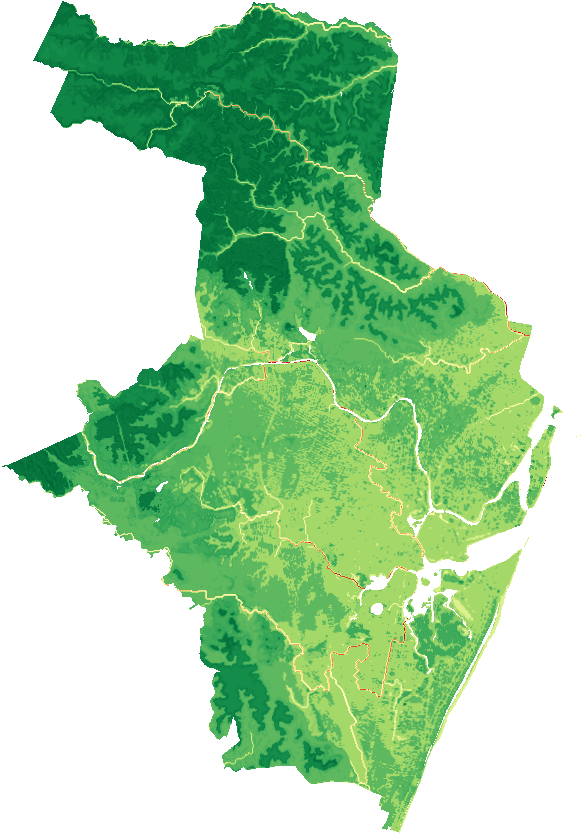

In [15]:
import folium
import matplotlib.cm as cm
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds

def raster_to_overlay_rgba(path: Path, cmap, vmin=None, vmax=None, opacity=0.6):
    path = Path(path)
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32, copy=False)
        nodata = src.nodata
        if nodata is not None and np.isfinite(nodata):
            data = np.where(data == nodata, np.nan, data)

        src_crs = src.crs
        if src_crs is None:
            raise RuntimeError(f'Raster sem CRS: {path}')

        # Reprojetar para EPSG:4326 (Folium)
        dst_crs = 'EPSG:4326'
        transform4326, width4326, height4326 = calculate_default_transform(
            src_crs, dst_crs, src.width, src.height, *src.bounds
        )
        dst = np.full((height4326, width4326), np.nan, dtype=np.float32)
        reproject(
            source=data,
            destination=dst,
            src_transform=src.transform,
            src_crs=src_crs,
            dst_transform=transform4326,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear,
            src_nodata=np.nan,
            dst_nodata=np.nan,
        )

        valid = np.isfinite(dst)
        if not valid.any():
            rgba = np.zeros((dst.shape[0], dst.shape[1], 4), dtype=np.uint8)
        else:
            vvmin = float(np.nanmin(dst)) if vmin is None else float(vmin)
            vvmax = float(np.nanmax(dst)) if vmax is None else float(vmax)
            if not np.isfinite(vvmin) or not np.isfinite(vvmax) or vvmax == vvmin:
                norm = np.zeros_like(dst, dtype=np.float32)
            else:
                norm = (dst - vvmin) / (vvmax - vvmin)
                norm = np.clip(norm, 0.0, 1.0)
            rgba_f = cmap(norm)
            rgba_f[..., 3] = np.where(valid, 1.0, 0.0)
            rgba = (rgba_f * 255).astype(np.uint8)

        b = array_bounds(height4326, width4326, transform4326)
        west, south, east, north = float(b[0]), float(b[1]), float(b[2]), float(b[3])
        bounds = [[south, west], [north, east]]
        return rgba, bounds, opacity

# Paths (recortados)
hecras_layer_path = hecras_recortado
ahp_inicial_path = Path(f'outputs/mapas_de_risco/risco_alagamento_{SLUG}_recortado_inicial.tif')
ahp_calibrado_path = Path(f'outputs/mapas_de_risco/risco_alagamento_{SLUG}_recortado_calibrado.tif')

if not ahp_inicial_path.exists():
    # fallback: se não tiver reexecutado a célula 2 após a edição
    ahp_inicial_path = Path(f'outputs/mapas_de_risco/risco_alagamento_{SLUG}_recortado.tif')
if not ahp_calibrado_path.exists():
    # fallback: usa o recortado atual
    ahp_calibrado_path = Path(f'outputs/mapas_de_risco/risco_alagamento_{SLUG}_recortado.tif')

# Centro do mapa (centroide do município em EPSG:4326)
gdf4326 = gdf.to_crs(epsg=4326) if (gdf.crs is None or str(gdf.crs).upper() != 'EPSG:4326') else gdf
centro = gdf4326.geometry.centroid.iloc[0]
m = folium.Map(location=[float(centro.y), float(centro.x)], zoom_start=11, tiles=None)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri',
    name='Satélite',
    overlay=False,
    control=True,
).add_to(m)

# Camadas
img_hec, bounds_hec, op_hec = raster_to_overlay_rgba(hecras_layer_path, cmap=cm.get_cmap('viridis'), opacity=0.6)
folium.raster_layers.ImageOverlay(
    name='HEC-RAS',
    image=img_hec,
    bounds=bounds_hec,
    opacity=op_hec,
    interactive=True,
    cross_origin=False,
    show=True,
).add_to(m)

# Para comparar inicial vs calibrado de forma justa, usar mesma escala de cores
with rasterio.open(ahp_inicial_path) as s0:
    arr0 = s0.read(1).astype(np.float32, copy=False)
    nd0 = s0.nodata
    if nd0 is not None and np.isfinite(nd0):
        arr0 = np.where(arr0 == nd0, np.nan, arr0)
with rasterio.open(ahp_calibrado_path) as s1:
    arr1 = s1.read(1).astype(np.float32, copy=False)
    nd1 = s1.nodata
    if nd1 is not None and np.isfinite(nd1):
        arr1 = np.where(arr1 == nd1, np.nan, arr1)
vmin = float(np.nanmin(np.concatenate([arr0[np.isfinite(arr0)], arr1[np.isfinite(arr1)]])))
vmax = float(np.nanmax(np.concatenate([arr0[np.isfinite(arr0)], arr1[np.isfinite(arr1)]])))

img_ini, bounds_ini, op_ini = raster_to_overlay_rgba(ahp_inicial_path, cmap=cm.get_cmap('RdYlGn_r'), vmin=vmin, vmax=vmax, opacity=0.6)
folium.raster_layers.ImageOverlay(
    name='AHP inicial',
    image=img_ini,
    bounds=bounds_ini,
    opacity=op_ini,
    interactive=True,
    cross_origin=False,
    show=False,
).add_to(m)

img_cal, bounds_cal, op_cal = raster_to_overlay_rgba(ahp_calibrado_path, cmap=cm.get_cmap('RdYlGn_r'), vmin=vmin, vmax=vmax, opacity=0.6)
folium.raster_layers.ImageOverlay(
    name='AHP calibrado',
    image=img_cal,
    bounds=bounds_cal,
    opacity=op_cal,
    interactive=True,
    cross_origin=False,
    show=True,
).add_to(m)

folium.LayerControl().add_to(m)
m